# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# PRACTICA No. 7. Redes Neuronales (SCIKIT-LEARN_MLPClassifier) PARA REALIZAR ANALISIS DE SENTIMIENTOS (DATASET CRITICAS DE CINE).
### En esta practica se implementará un modelo Word2Vec para la clasificación de sentimientos en críticas de cine utilizando la librería Gensim.

## Paso 1: Importamos las librerías necesarias

In [36]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

## Paso 2: Cargamos el dataset de críticas de cine y datos para el procesamiento de texto

In [37]:
movie_reviews = pd.read_csv("../data/movie_data.csv")
stop_words = set(stopwords.words("english"))

movie_reviews['review'] = movie_reviews['review'].str.lower()
movie_reviews = movie_reviews.dropna()

movie_reviews

,review,sentiment
0,"in 1974, the teenager martha moxley (maggie gr...",1
1,ok... so... i really like kris kristofferson a...,0
2,"***spoiler*** do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"i recently bought the dvd, forgetting just how...",0
...,...,...
49995,"ok, lets start with the best. the building. al...",0
49996,the british 'heritage film' industry is out of...,0
49997,i don't even know where to begin on this one. ...,0
49998,richard tyler is a little boy who is scared of...,0


In [38]:
misspell_data = pd.read_csv("../data/aspell.txt", sep=":", names=["correction", "misspell"])
misspell_data["correction"] = misspell_data["correction"].str.lower()
misspell_data["misspell"] =  misspell_data["misspell"].str.strip()
misspell_data["misspell"] =  misspell_data["misspell"].str.split(" ")
misspell_data = misspell_data.explode('misspell').reset_index(drop=True)

# Creamos un diccionario para corregir las palabras mal escritas
miss2correction = dict(
  zip(misspell_data["misspell"], misspell_data["correction"])
)


In [39]:
contractions_first = pd.read_csv("../data/contractions.csv", sep=",")

# Creamos un diccionario para expandir las contracciones
contr2meaning = dict(
  zip(contractions_first["contraction"], contractions_first["meaning"])
)

print(f"Contracciones del Dataset: {len(contr2meaning)}")

Contracciones del Dataset: 148


In [40]:
contractions_second = None

with open("../data/contractions.json", "r", encoding="utf-8") as f:
  contractions_second = json.load(f)
  
print(f"Contracciones del Dataset: {len(contractions_second)}")

Contracciones del Dataset: 118


In [41]:
print(f"Contracciones totales: {len(contr2meaning) + len(contractions_second)}")

contr2meaning.update(contractions_second)

print(f"Contracciones totales después de la actualización: {len(contr2meaning)}")

Contracciones totales: 266
Contracciones totales después de la actualización: 182


## Paso 3: Creamos la función de limpieza para las críticas de cine

In [46]:
def clean_review(review: str) -> str:
  # Aglunas críticas tienen el tag "<br />", no queremos eso
  review = review.replace("<br />", " ").strip()
  words = review.split()
  
  for word in words:
    if word in miss2correction.keys():
      review = review.replace(word, miss2correction[word])
      
    if word in contr2meaning.keys():
      review = review.replace(word, contr2meaning[word])
      
  # Tokenizamos el texto y eliminamos las palabras vacías (stop words)
  # NOTA: solo separa las palabras, no crea tokens como los LLMs
  tokens = word_tokenize(review)
      
  return " ".join([
    word for word in tokens
    if word.isalpha() and word not in stop_words
  ])
  
# Testeamos la función de limpieza con una crítica de ejemplo
example_review = movie_reviews["review"].iloc[13]
print(f"Crítica original:\n{example_review}\n")
print(f"Crítica limpia:\n{clean_review(example_review)}")

Crítica original:
what is it about the french? first, they (apparently) like jerry lewis a lot more than the us does. second, they (seem) to like edgar allan poe's work more than just about anyone else does. it's got to be the "beaudelaire effect".<br /><br />don't get me wrong...i'm a poe fan myself. but this trilogy manages to make three of poe's below-average stories into...well, i'm not sure what they're made into.<br /><br />"toby dammit" is a fine fellini film, but it has nothing to do with poe's story, at least in terms of theme. it's enjoyable on the first viewing. terence stamp does a good job with an interesting role. however, it has nothing whatsoever to do with poe or spirits of the dead.<br /><br />"metzergenstein" is a big mess. how did vadim's films get produced? it's just awful...not even up to amateur film school standards. depending on the dvd menu you have, try to skip it and save your time.<br /><br />"william wilson" is actually the segment that is most faithful to

## Paso 4: Limpieza de las críticas de cine

In [48]:
movie_reviews["clean_review"] = movie_reviews["review"].apply(clean_review)

In [49]:
movie_reviews["clean_review"].head(20)

0     teenager martha moxley maggie grace moves area...
1     ok really like kris kristofferson usual easy g...
2     spoiler read think watching movie although wou...
3     hi people seen wonderful movie im sure thet wo...
4     recently bought dvd forgetting much hated movi...
5     leave braik put good show finally zorak living...
6     nathan detroit frank sinatra manager new york ...
7     understand crash course right context must und...
8     impressed chavez stance globalisation sometime...
9     movie directed renny harlin finnish miracle st...
10    lived let tell foggyest idea heck bear walk ne...
11    hidden frontier notable longest running star t...
12    ago seen sleuth two great actors michael caine...
13    french first apparently like jerry lewis lot u...
14    strange movie unlike anything made west time t...
15    saw movie strength single positive review imag...
16    great philosophical questions purpose life hap...
17    cast surfer dude beach scenes almost got c

## Paso 5: Tokenización de las críticas de cine

In [54]:
tokenized_reviews = movie_reviews["clean_review"].str.split().tolist()
tokenized_reviews[0][:10]

['teenager',
 'martha',
 'moxley',
 'maggie',
 'grace',
 'moves',
 'area',
 'belle',
 'greenwich',
 'connecticut']

## Paso 6: Entrenamiento del modelo Word2Vec para generar los vectores necesarios

In [55]:
word2vec_model = Word2Vec(
  tokenized_reviews,
  vector_size=512,
  window=5,
  workers=4,
  min_count=3,
  sg=1
)

In [60]:
word2vec_model.save("../models/trainable_models/word2vec/word2vec.model")
word2vec_model.wv.save("../models/word_vectors.wordvectors")

## Paso 7: Creamos la función para pasar de una critica a su vector correspondiente

In [64]:
def convert_to_vector(review: str) -> np.ndarray:
  return word2vec_model.wv.get_mean_vector(review.split(" "))

# Testeamos la función de conversión con una crítica de ejemplo
example_review = movie_reviews["clean_review"].iloc[13]
embedding_vector = convert_to_vector(example_review)
print(embedding_vector.shape)
print(embedding_vector[:10])

(512,)
[-0.00685203 -0.00760577 -0.01731236  0.0031071   0.00672405  0.00833429
  0.02038645 -0.00083778  0.00124207  0.0113275 ]


## Paso 8: Creamos los datos necesarios para el entrenamiento y los separamos en conjuntos de entrenamiento y prueba

In [66]:
y = movie_reviews["sentiment"]
X = movie_reviews["clean_review"].apply(convert_to_vector)
X = pd.DataFrame(X.tolist())

y, X

(0        1
 1        0
 2        0
 3        1
 4        0
         ..
 49995    0
 49996    0
 49997    0
 49998    0
 49999    1
 Name: sentiment, Length: 50000, dtype: int64,
             0         1         2         3         4         5         6    \
 0     -0.004586 -0.008012 -0.023867 -0.007193  0.015961  0.016975  0.015571   
 1     -0.013950 -0.011589 -0.013230  0.015525  0.012100  0.020526  0.023459   
 2     -0.009730 -0.013551 -0.011414  0.006463  0.001050  0.018643  0.019460   
 3     -0.034488  0.000122 -0.024555 -0.005250 -0.015018  0.019313  0.012665   
 4     -0.010755 -0.008975 -0.013387  0.013869  0.004963  0.021369  0.011042   
 ...         ...       ...       ...       ...       ...       ...       ...   
 49995 -0.012236 -0.001845 -0.005345  0.017248  0.003460  0.012553  0.020592   
 49996 -0.005412 -0.021840 -0.020752  0.012204  0.008585  0.018109  0.027222   
 49997 -0.000571 -0.004624 -0.018331  0.022566  0.001932  0.013790  0.019351   
 49998 -0.008737 -0.0

In [67]:
X.shape, y.shape

((50000, 512), (50000,))

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=42)

## Paso 9: Entrenamos el modelo MLPClassifier con los datos de entrenamiento

In [69]:
mlp_model = MLPClassifier()
mlp_model.fit(X_train, y_train)

d:\tareas y trabajos\UNI 10°\machine-learning-deep-learning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [70]:
predicts = mlp_model.predict(X_test)
predicts

array([0, 0, 1, ..., 1, 1, 0], shape=(15000,))

## Paso 10: Evaluamos el modelo con los datos de prueba y mostramos las métricas de evaluación

In [71]:
accuracy = accuracy_score(y_test, predicts)
print(f"Precisión: {accuracy:.4f}")

Precisión: 0.8891


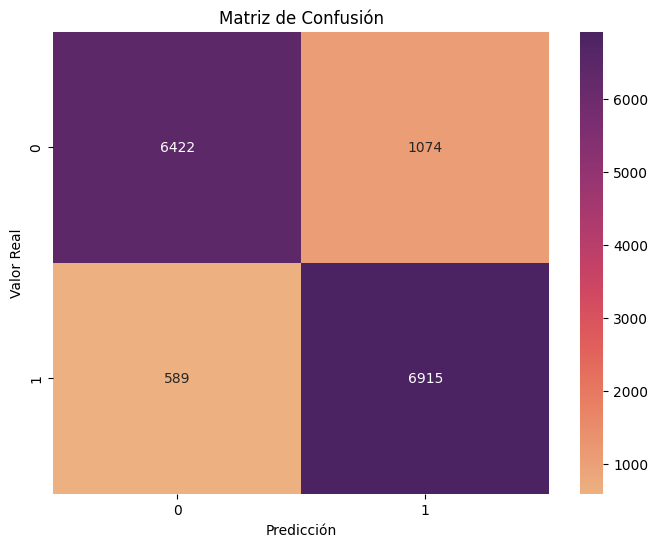

In [72]:
confusion_m = confusion_matrix(y_test, predicts)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='flare')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

## Conclusiones.
### En esta práctica se creo un modelo para el análisis de sentimientos utilizando Word2Vec y MLPClassifier. Para obtener los vectores se limpiaron las criticas de cine para posteriormente entrenar un modelo Word2Vec con Skip-Gram. Luego se creó una función para convertir cada crítica en un vector promedio de las palabras que la componen. Finalmente, se entrenó un modelo MLPClassifier con los vectores obtenidos y se evaluó su desempeño utilizando métricas como la precisión y la matriz de confusión. Logrando una precisión del .88 o 88% en la clasificación de sentimientos en las críticas de cine.

## Referencias

### SCIKIT-LEARN (Machine Learning in Python 2025). URL: https://scikit-learn.org/stable/modules/linear_model.html#perceptron (Ultimo acceso febrero 2025).

### Gensim: topic modelling for humans. (s. f.). https://radimrehurek.com/gensim/models/word2vec.html

### NLTK :: nltk.tokenize package. (s. f.). https://www.nltk.org/api/nltk.tokenize.html#nltk.tokenize.word_tokenize

### GeeksforGeeks. (2025, 23 julio). Word2Vec with Gensim. GeeksforGeeks. https://www.geeksforgeeks.org/nlp/word2vec-with-gensim/